In [32]:
!curl -L "https://drive.google.com/uc?export=download&id=1uCRIl4C1V-a5E11lImbW6q244BN80yKT" -o ../data/sample_2.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 7373k  100 7373k    0     0  3811k      0  0:00:01  0:00:01 --:--:-- 14.5M


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,sellingprice,saledate
0,2013,Hyundai,Elantra,Limited,Sedan,automatic,5npdh4ae1dh194798,fl,25.0,32997.0,black,gray,hyundai motor finance,13200.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)
1,2008,NaN,NaN,NaN,NaN,automatic,1fdns24l58da70495,ga,33.0,85037.0,black,black,akins ford dodge jeep chrysler,17800.0,Thu Jan 15 2015 02:00:00 GMT-0800 (PST)
2,2011,Nissan,Maxima,3.5 SV,Sedan,automatic,1n4aa5ap0bc867447,mo,42.0,65192.0,white,beige,nissan-infiniti lt,15700.0,Wed Feb 18 2015 02:30:00 GMT-0800 (PST)
3,2014,Chevrolet,Impala,LT,Sedan,NaN,2g1125s35e9281298,co,3.0,27296.0,white,gray,gm remarketing,23100.0,Tue Jun 16 2015 04:30:00 GMT-0700 (PDT)
4,2013,Chevrolet,Silverado 1500,LT,Extended Cab,automatic,1gcrcse04dz214378,ga,45.0,20770.0,silver,black,young motors llc,23300.0,Tue Jan 06 2015 01:30:00 GMT-0800 (PST)


In [40]:
print(df.shape)
df.info()

(50000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          50000 non-null  int64  
 1   make          49067 non-null  object 
 2   model         49061 non-null  object 
 3   trim          49024 non-null  object 
 4   body          48806 non-null  object 
 5   transmission  44143 non-null  object 
 6   vin           49999 non-null  object 
 7   state         50000 non-null  object 
 8   condition     48954 non-null  float64
 9   odometer      49991 non-null  float64
 10  color         49928 non-null  object 
 11  interior      49928 non-null  object 
 12  seller        50000 non-null  object 
 13  sellingprice  49996 non-null  float64
 14  saledate      49996 non-null  object 
dtypes: float64(3), int64(1), object(11)
memory usage: 5.7+ MB


In [41]:
df.isnull().sum()

year               0
make             933
model            939
trim             976
body            1194
transmission    5857
vin                1
state              0
condition       1046
odometer           9
color             72
interior          72
seller             0
sellingprice       4
saledate           4
dtype: int64

In [42]:
df['make'].fillna(df['make'].mode()[0], inplace=True)
df['model'].fillna(df['model'].mode()[0], inplace=True)
df['trim'].fillna(df['trim'].mode()[0], inplace=True)
df['body'].fillna(df['body'].mode()[0], inplace=True)
df['transmission'].fillna(df['transmission'].mode()[0], inplace=True)
df['color'].fillna(df['color'].mode()[0], inplace=True)
df['interior'].fillna(df['interior'].mode()[0], inplace=True)
df['condition'].fillna(df['condition'].median(), inplace=True)
df['odometer'].fillna(df['odometer'].median(), inplace=True)
df.dropna(inplace=True)

df.isnull().sum()

/tmp/ipykernel_187/3941645576.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['make'].fillna(df['make'].mode()[0], inplace=True)
/tmp/ipykernel_187/3941645576.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

year            0
make            0
model           0
trim            0
body            0
transmission    0
vin             0
state           0
condition       0
odometer        0
color           0
interior        0
seller          0
sellingprice    0
saledate        0
dtype: int64

In [43]:
df.describe()

,year,condition,odometer,sellingprice
count,49995.000000,49995.000000,49995.000000,49995.000000
mean,2010.022522,30.673807,68518.399060,13606.972837
std,3.988975,13.286876,53599.178211,9780.754443
min,1986.000000,1.000000,1.000000,100.000000
25%,2007.000000,24.000000,28320.500000,6900.000000
50%,2012.000000,34.000000,52384.000000,12200.000000
75%,2013.000000,41.000000,99544.500000,18200.000000
max,2015.000000,49.000000,999999.000000,169000.000000


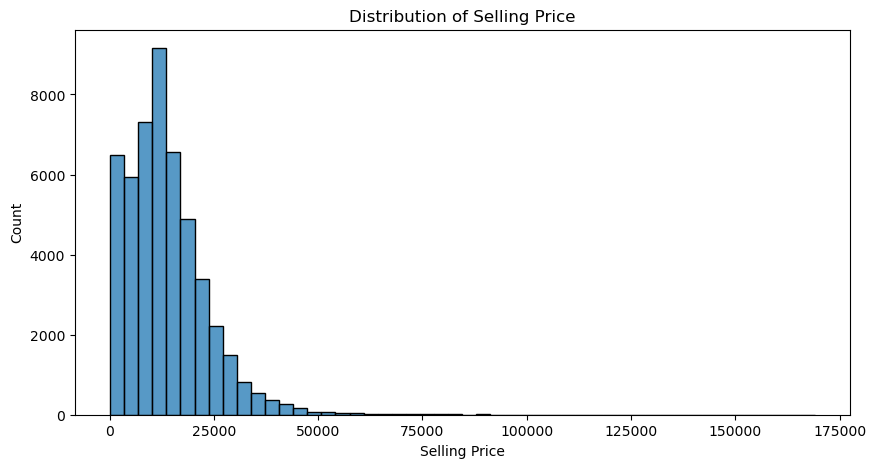

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(df['sellingprice'], bins=50)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.show()

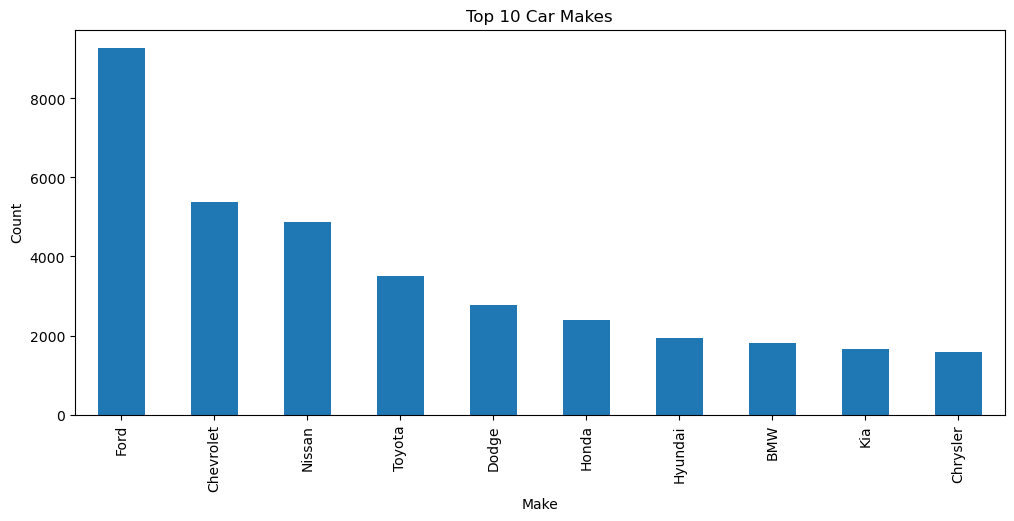

In [45]:
plt.figure(figsize=(12, 5))
df['make'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Car Makes')
plt.xlabel('Make')
plt.ylabel('Count')
plt.show()

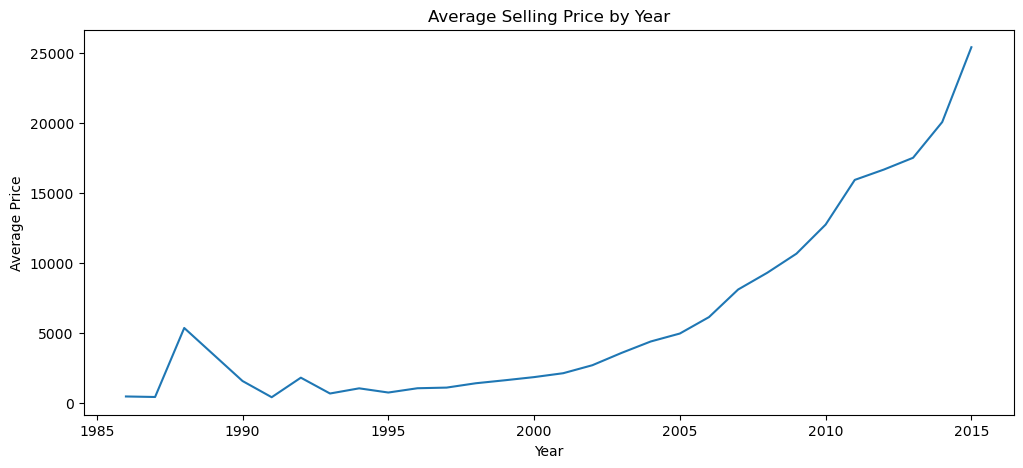

In [46]:
plt.figure(figsize=(12, 5))
df.groupby('year')['sellingprice'].mean().plot(kind='line')
plt.title('Average Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.show()

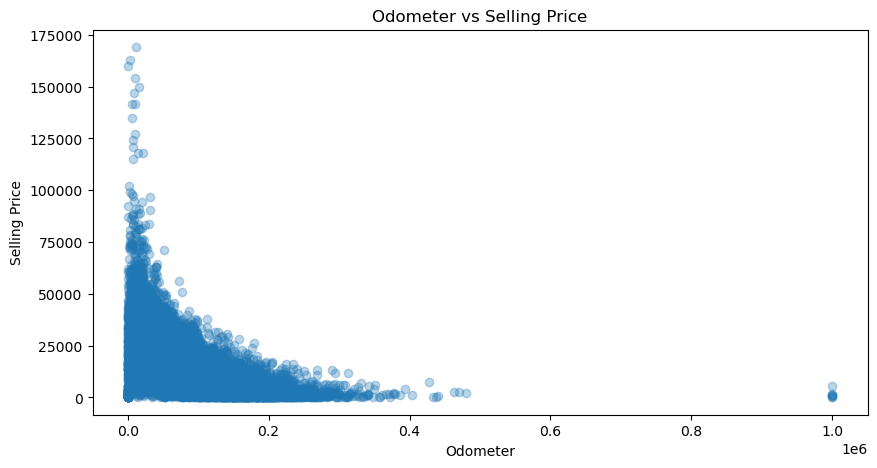

In [47]:
plt.figure(figsize=(10, 5))
plt.scatter(df['odometer'], df['sellingprice'], alpha=0.3)
plt.title('Odometer vs Selling Price')
plt.xlabel('Odometer')
plt.ylabel('Selling Price')
plt.show()

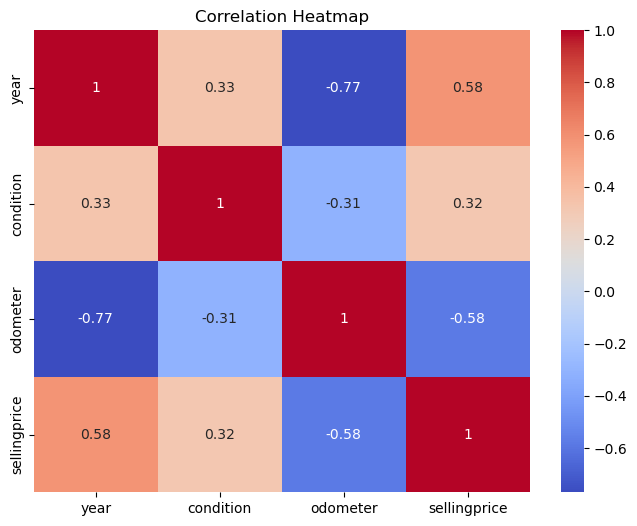

In [48]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['year', 'condition', 'odometer', 'sellingprice']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Conclusions: Feature Importance for Selling Price Prediction

**Most important features:**
- `year` — correlation 0.58 with price. Newer cars are more expensive.
- `odometer` — correlation -0.58 with price. More mileage = lower price.
- `condition` — correlation 0.32. Better condition = higher price.

**Features that are hard to process:**
- `vin` — unique identifier for each car, not useful for prediction.
- `saledate` — date in text format, needs parsing to extract useful info.
- `seller` — too many unique values, hard to encode effectively.
- `make`, `model`, `trim` — categorical with hundreds of unique values, need careful encoding.